In [15]:
import numpy as np 
import matplotlib.pyplot as plt
import math
from scipy.integrate import odeint
Used_Student_ID="2300144"
X=int(Used_Student_ID[5])
Y=X=int(Used_Student_ID[6])
print(X,Y)

4 4


In [66]:
X = 4
Y = 4
L = (200+30*X)*1e-4
R = 0.3+0.02*Y
W = 2e-4 # cm
D = 0.2e-4 # cm
GAMMA = 0.3
NG = 4
ALPHA_INT = 40
B = 2.5e-16 # cm^-2
N0 = 1e18 # cm^-3
TAU = 2.2e-9 # s
BETA_SP = 1e-4
I_input=50*1e-3


In [79]:
I=0
C0=3e10
C=C0/NG
q=1.6*1e-19
N=0
ALPHA_INT = 40
S=0
ALPHA_M=(1/2*L)*(np.log((1/R*R)))
ALPHA_T=ALPHA_M+ALPHA_INT
tau_ph=1/(C*ALPHA_T)
V=L * W * D 


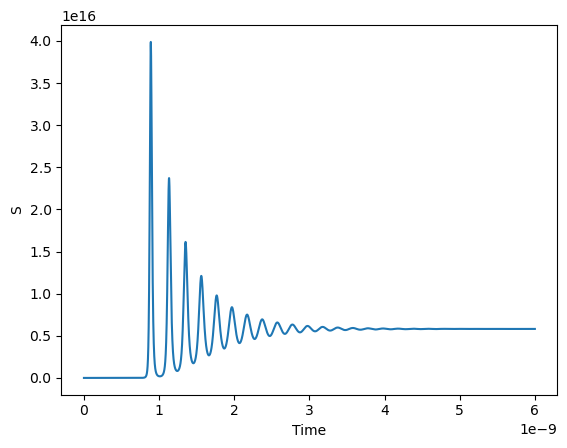

In [85]:
t =np.linspace(0,6e-9,10000)
##y = odeint(dydt, y0, t)
def dydt(y, t):
    N, S = y

    gain = B * max(N - N0, 0)

    injection = I_input / (q * V)

    dndt = injection - (N / TAU) - GAMMA * C * gain * S

    dsdt = GAMMA * C * gain * S - (S / tau_ph) + (BETA_SP * N / TAU)

    return [dndt, dsdt]
initial_conditions=[0,0]            
soln= odeint (dydt,initial_conditions,t)
N_s = soln[:,0]
S_s = soln[:,1]
plt.plot(t, S_s)
plt.xlabel("Time")
plt.ylabel("S")
plt.show()